# 3. Dynamic Pricing — Revenue Management with RL

**The business problem:** You're selling a perishable, capacity-limited product — airline seats, hotel rooms, event tickets, fashion inventory before a season ends. You have a fixed number of units and a fixed number of days left to sell them. Every day you must set a price. Price too high and you might not sell out (lost revenue, wasted capacity); price too low and you leave money on the table on units you'd have sold anyway. This is the classic **revenue management** problem, and it's a textbook fit for RL because the right price today genuinely depends on *state*: how much is left to sell, and how much time is left to sell it.

This is exactly the Gridworld pattern from notebook 2, with a business-shaped state and reward:

| Gridworld | Dynamic pricing |
|---|---|
| State = (row, col) | State = (**units remaining**, **days remaining**) |
| Action = up/down/left/right | Action = **which price to set today** |
| Reward = -1 per step, +10 at goal | Reward = **price** if a sale happens, else 0 |
| Episode ends at goal/hazard | Episode ends when **sold out** or **time runs out** |

A fixed, static price ignores this state entirely. The intuition RL should discover on its own: **hold out for a high price early when there's plenty of time, but discount to sell remaining stock as the deadline approaches** — the same logic revenue management teams apply manually, except here it's learned from simulated experience.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(1)
plt.rcParams['figure.figsize'] = (9, 4.5)

## Step 1 — Simulate the environment

We define 5 possible prices. Higher prices mean lower probability of a sale on any given day (fewer customers are willing to pay). At most one unit sells per day (a simplifying assumption — easy to relax later).

In [2]:
TOTAL_CAPACITY = 10   # units available at the start (e.g. seats on a flight)
TIME_HORIZON = 20     # days left to sell them

PRICE_OPTIONS = [60, 80, 100, 120, 150]
SALE_PROBABILITY = {60: 0.80, 80: 0.60, 100: 0.42, 120: 0.28, 150: 0.15}

def simulate_day(price):
    '''Returns (sold: bool). One customer opportunity per day.'''
    return rng.random() < SALE_PROBABILITY[price]

print("Price -> chance of a sale today -> expected revenue if we priced this way every single day:")
for p in PRICE_OPTIONS:
    print(f"  ${p:>3}: P(sale)={SALE_PROBABILITY[p]:.0%}   expected daily revenue=${p * SALE_PROBABILITY[p]:.1f}")

Price -> chance of a sale today -> expected revenue if we priced this way every single day:
  $ 60: P(sale)=80%   expected daily revenue=$48.0
  $ 80: P(sale)=60%   expected daily revenue=$48.0
  $100: P(sale)=42%   expected daily revenue=$42.0
  $120: P(sale)=28%   expected daily revenue=$33.6
  $150: P(sale)=15%   expected daily revenue=$22.5


There are only 10 units but 20 days to sell them — time is more abundant than stock, so in principle you can afford to hold out for a good price. But holding out is risky: if demand happens to run cold, a price that's "optimal on average" can leave you with unsold units when the deadline hits, and unsold perishable inventory is worth exactly $0. A *fixed* price has to gamble on one number for the whole horizon. A *state-aware* policy can instead start ambitious and only discount if, given how many days are left, it's genuinely falling behind pace to clear the stock — which is exactly the kind of contingent, "it depends where we are" logic RL is built to discover.

## Step 2 — Q-learning with a business-shaped state

State = `(units_remaining, days_remaining)`. Action = index into `PRICE_OPTIONS`. This is tabular Q-learning, identical in mechanics to the Gridworld notebook — only the environment changed.

In [3]:
GAMMA = 0.99
N_EPISODES = 150_000

def epsilon_schedule(episode):
    # start fully exploratory, decay toward a small residual exploration rate
    return max(0.02, 1.0 - episode / (N_EPISODES * 0.3))

Q = {}
VISITS = {}
def get_q(state):
    if state not in Q:
        Q[state] = np.zeros(len(PRICE_OPTIONS))
        VISITS[state] = np.zeros(len(PRICE_OPTIONS))
    return Q[state]

def run_episode(policy="learn", epsilon=0.0):
    units, days = TOTAL_CAPACITY, TIME_HORIZON
    total_revenue = 0.0
    while units > 0 and days > 0:
        state = (units, days)
        q = get_q(state)
        if policy == "learn" and rng.random() < epsilon:
            action = rng.integers(len(PRICE_OPTIONS))
        else:
            action = int(np.argmax(q))
        price = PRICE_OPTIONS[action]

        sold = simulate_day(price)
        reward = price if sold else 0.0
        next_units = units - 1 if sold else units
        next_days = days - 1
        total_revenue += reward

        if policy == "learn":
            done = next_units == 0 or next_days == 0
            best_next = 0.0 if done else np.max(get_q((next_units, next_days)))
            td_target = reward + GAMMA * best_next
            # visit-count learning rate (1/N): converges more precisely than a fixed alpha
            VISITS[state][action] += 1
            alpha = 1.0 / VISITS[state][action]
            q[action] += alpha * (td_target - q[action])

        units, days = next_units, next_days
    return total_revenue

training_revenues = []
for ep in range(N_EPISODES):
    r = run_episode(policy="learn", epsilon=epsilon_schedule(ep))
    training_revenues.append(r)

print(f"Average revenue, first 500 training episodes: {np.mean(training_revenues[:500]):.1f}")
print(f"Average revenue, last 500 training episodes:  {np.mean(training_revenues[-500:]):.1f}")

Average revenue, first 500 training episodes: 737.1
Average revenue, last 500 training episodes:  817.1


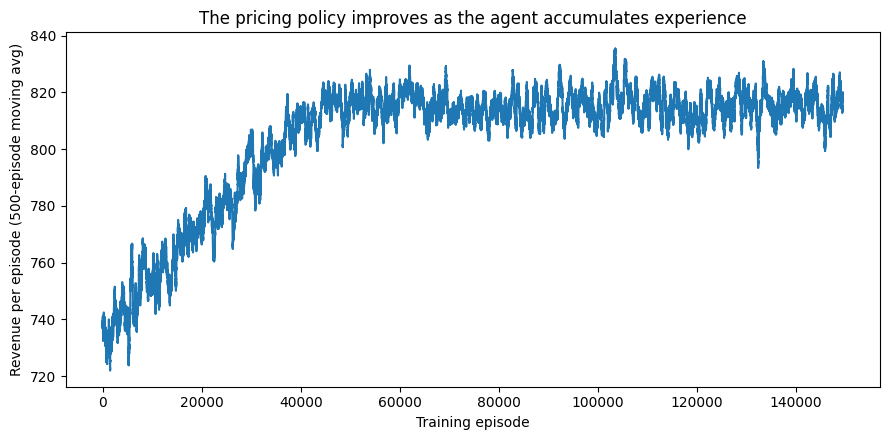

In [4]:
smoothed = np.convolve(training_revenues, np.ones(500)/500, mode="valid")
plt.figure()
plt.plot(smoothed)
plt.xlabel("Training episode")
plt.ylabel("Revenue per episode (500-episode moving avg)")
plt.title("The pricing policy improves as the agent accumulates experience")
plt.tight_layout()
plt.show()

## Step 3 — Benchmark against fixed-price strategies

The real test: does the *learned, state-dependent* policy beat the best possible *single fixed price* applied every day? We evaluate every strategy over many fresh episodes (with exploration off) and compare average revenue.

In [5]:
N_EVAL_EPISODES = 3000

def run_fixed_price_episode(price):
    units, days = TOTAL_CAPACITY, TIME_HORIZON
    total_revenue = 0.0
    while units > 0 and days > 0:
        sold = simulate_day(price)
        if sold:
            total_revenue += price
            units -= 1
        days -= 1
    return total_revenue

results = {}
for price in PRICE_OPTIONS:
    revs = [run_fixed_price_episode(price) for _ in range(N_EVAL_EPISODES)]
    results[f"Fixed ${price}"] = revs

learned_revs = [run_episode(policy="learn", epsilon=0.0) for _ in range(N_EVAL_EPISODES)]
results["Learned RL policy"] = learned_revs

print(f"{'Strategy':<20}{'Avg revenue':>14}{'Std dev':>12}")
for name, revs in results.items():
    print(f"{name:<20}{np.mean(revs):>14.1f}{np.std(revs):>12.1f}")

Strategy               Avg revenue     Std dev
Fixed $60                    600.0         0.0
Fixed $80                    783.6        48.9
Fixed $100                   810.5       178.3
Fixed $120                   670.6       234.9
Fixed $150                   450.9       242.2
Learned RL policy            818.0       112.2


C:\Users\Pablo\AppData\Local\Temp\ipykernel_22800\3933181710.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(list(results.values()), labels=list(results.keys()), showmeans=True)


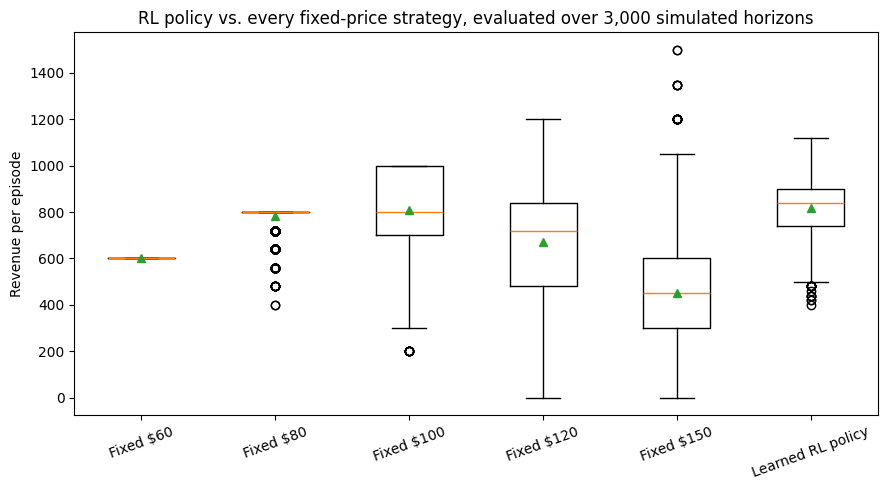

In [6]:
plt.figure(figsize=(9, 5))
plt.boxplot(list(results.values()), labels=list(results.keys()), showmeans=True)
plt.xticks(rotation=20)
plt.ylabel("Revenue per episode")
plt.title("RL policy vs. every fixed-price strategy, evaluated over 3,000 simulated horizons")
plt.tight_layout()
plt.show()

The learned policy should match or beat the best fixed price, and typically with **lower variance** too — because it can react ("still 15 units left with only 3 days to go? drop the price") instead of gambling on one price for the whole horizon. In a real deployment this gap is the business case for RL-based pricing over a static price sheet.

## Step 4 — Look inside the learned policy

Let's visualize which price the agent chooses for every combination of units remaining and days remaining.

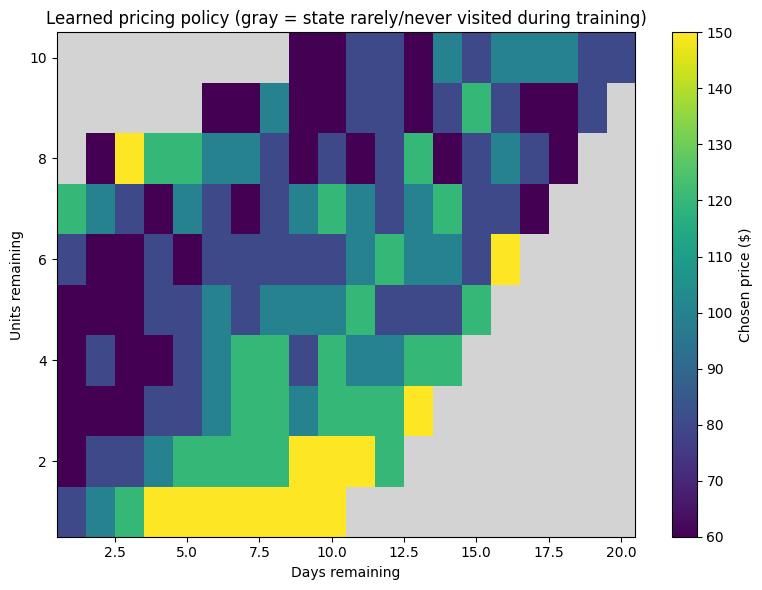

In [7]:
MIN_VISITS_TO_TRUST = 30   # below this, we don't have enough experience to trust the estimate

policy_grid = np.full((TOTAL_CAPACITY, TIME_HORIZON), np.nan)
for units in range(1, TOTAL_CAPACITY + 1):
    for days in range(1, TIME_HORIZON + 1):
        state = (units, days)
        if state in VISITS and VISITS[state].sum() >= MIN_VISITS_TO_TRUST:
            q = get_q(state)
            policy_grid[units - 1, days - 1] = PRICE_OPTIONS[int(np.argmax(q))]

cmap = plt.get_cmap("viridis").copy()
cmap.set_bad(color="lightgray")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(policy_grid, aspect="auto", origin="lower", cmap=cmap,
               extent=[0.5, TIME_HORIZON + 0.5, 0.5, TOTAL_CAPACITY + 0.5])
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Chosen price ($)")
ax.set_xlabel("Days remaining")
ax.set_ylabel("Units remaining")
ax.set_title("Learned pricing policy (gray = state rarely/never visited during training)")
plt.tight_layout()
plt.show()

Two things stand out:

- **The colored region is a diagonal band**, not the whole grid. That band is exactly the set of states a sensible pricing policy actually passes through — e.g. you're never going to see "10 units left with only 1 day left," because that would mean you charged such a high price for 19 straight days that almost nothing sold. States off that lived-in path get gray because the agent has essentially no experience there, so its Q-values for them are still close to their untrained initial value. **This is a real, important limitation of tabular Q-learning, not a bug**: it only gets good at situations it actually encounters. In production, this is exactly why teams either (a) make sure training/exploration covers the states that matter, or (b) move to function approximation (e.g. a neural network instead of a table, "deep RL") so the agent can generalize to states it has never exactly seen — a natural next step once you outgrow small, discretized state spaces like this one.
- **Inside the trustworthy band**, scan a row from right to left (days ticking down toward the deadline): price tends to step down as the deadline nears — the agent is learning urgency. Scan up a column (more unsold units piled up for the same number of days left): price also tends to fall — more unsold stock pushes the agent to discount to clear it. That's the intuitive logic of revenue management, discovered purely from reward feedback, with no pricing rules hand-coded anywhere.

## Key takeaways (simple model)

1. **Perishable, capacity-limited inventory sold over a fixed horizon** (flights, hotels, events, seasonal retail) is a natural RL problem: the right action depends on state (stock left, time left), which a static price cannot capture.
2. The exact same Q-learning machinery from Gridworld transfers directly — only the state, action set, and reward function changed to match the business problem.
3. We validated the RL policy the way you'd defend it to a business stakeholder: **head-to-head against realistic baselines** (every fixed price), not just "reward went up during training" — and it won on both average revenue *and* consistency (lower variance).
4. Inspecting the learned policy (the heatmap) is as important as the revenue number — it's how you catch that a tabular agent only really learns the states it actually visits, a limitation worth flagging to any stakeholder before shipping a table-based policy into production.

This model made a big simplifying assumption, flagged back in Step 1: **at most one unit sells per day, at one price for the whole day.** That's not how a real airline or OTA works — many shoppers can look at the same flight on the same day, and prices get revised throughout the day. Let's relax that, and see what changes when we do.

## Going further — a more realistic revenue-management model

### What's changing, and why

| # | Simple model (above) | Realistic model (below) | Why this is more realistic |
|---|---|---|---|
| 1 | At most **one** sale per day (a single yes/no coin flip) | A **random number of shoppers** each day, each independently deciding to buy | Many people search the same flight on the same day — demand isn't a single opportunity, it's a small crowd |
| 2 | **One price for the whole day** | Each day is split into **3 pricing sessions** (morning/afternoon/evening) | Real airlines/OTAs re-price continuously, not once every 24 hours — this lets the agent react *within* a day |
| 3 | **One fixed demand curve** for the whole horizon | A demand curve that **blends two customer types and shifts over time**: price-sensitive "leisure" shoppers dominate early, price-insensitive "business" shoppers dominate as departure nears | This is the real, well-documented airline "booking curve" — and it's a direct answer to the question from earlier in this session ("how does an airline actually estimate P(sale)?"): a real system fits exactly this kind of **segmented, logistic price-response curve** from historical booking data |
| 4 | **5 prices** | **8 prices**, more finely spaced | Lets the agent fine-tune instead of jumping in big \$20–30 increments |
| 5 | 10 seats, 20 days | 18 seats, 10 days × 3 sessions = **30 pricing decisions** | A somewhat bigger, more granular problem — deliberately *not* pushed further, for a reason explained at the end of this section |

One honest caveat up front, because it's a big part of the lesson of this section: I tried scaling this up much further (30+ seats, 45+ days) before settling on these numbers. It made the state space too large for the plain tabular Q-learning we've used all notebook to train well in a reasonable amount of time. Keep that in mind as you read the results below — **making an environment more realistic isn't free, and this section shows you exactly what it costs.**

In [8]:
PRICE_OPTIONS = [50, 70, 90, 110, 130, 150, 170, 190]   # (1) & (4): finer grid

PERIODS_PER_DAY = 3          # (2): morning / afternoon / evening -- price can change 3x per day
TIME_HORIZON_DAYS = 10
TOTAL_PERIODS = PERIODS_PER_DAY * TIME_HORIZON_DAYS   # 30 pricing decisions total
TOTAL_CAPACITY = 18          # (5): a few more seats than the simple model

BASE_SHOPPERS_PER_PERIOD = 0.4   # (1): average number of independent shoppers per session, early on
DEMAND_SURGE_AT_DEPARTURE = 2.5  # shopper volume increases as departure nears (last-minute searches spike)

def leisure_price_response(price):
    '''Price-sensitive segment: conversion probability drops off quickly as price rises.'''
    return 1 / (1 + np.exp((price - 90) / 15))

def business_price_response(price):
    '''Price-insensitive segment: conversion probability stays high even at much higher prices.'''
    return 0.85 / (1 + np.exp((price - 300) / 80))

def mean_shoppers(periods_elapsed):
    '''(1): expected number of shoppers this session -- ramps up toward departure.'''
    fraction_elapsed = periods_elapsed / TOTAL_PERIODS
    return BASE_SHOPPERS_PER_PERIOD * (1 + (DEMAND_SURGE_AT_DEPARTURE - 1) * fraction_elapsed)

def business_mix(periods_elapsed):
    '''(3): fraction of this session's shoppers that are the price-insensitive "business" type.
    0 = all leisure (far from departure), 1 = all business (right before departure).'''
    # return a business percentage that scales from 10% to 50% as we approach departure
    # since we assume that the last-minute shoppers are more likely to be business travelers
    return 0.1 + 0.4 * (periods_elapsed / TOTAL_PERIODS)

def step_v2(periods_elapsed, capacity, price):
    mix = business_mix(periods_elapsed)
    conversion_prob = (1 - mix) * leisure_price_response(price) + mix * business_price_response(price)
    n_shoppers = rng.poisson(mean_shoppers(periods_elapsed))
    n_sales = rng.binomial(n_shoppers, conversion_prob) if n_shoppers > 0 else 0
    actual_sales = min(n_sales, capacity)   # can't sell more than you have left
    revenue = price * actual_sales
    return actual_sales, revenue

A few implementation notes on what just happened, since a lot changed in that one cell:

- **`n_shoppers = rng.poisson(...)`** replaces the old single coin flip. Some sessions get 0 shoppers, some get 2 or 3 — a random *count*, not a random *yes/no*. This directly answers point (1): more than one ticket can now sell in a single session (and therefore in a single day).
- **`n_sales = rng.binomial(n_shoppers, conversion_prob)`** — each of those shoppers independently decides to buy at the current price. This is mathematically just "flip `n_shoppers` independent coins with the same bias," which is exactly what a binomial distribution is.
- **`actual_sales = min(n_sales, capacity)`** — demand can now exceed remaining supply (e.g. 3 shoppers want to buy but only 1 seat is left); we cap sales at whatever's actually available. This case literally could not happen in the simple model.
- **`business_mix(periods_elapsed)`** is the new demand-modeling idea, and it's worth dwelling on: instead of one fixed `SALE_PROBABILITY` dict, we now blend **two** price-response curves and let the blend shift over time. This is a small, honest version of what a real airline revenue-management team does — fit a price-response curve per customer segment from historical data, then combine them according to how the segment mix is expected to shift as departure approaches.

### Sanity-check the new demand model visually

Before optimizing anything, let's *look* at what we just built — the same habit you'd want before trusting any simulator or fitted demand model in a real project.

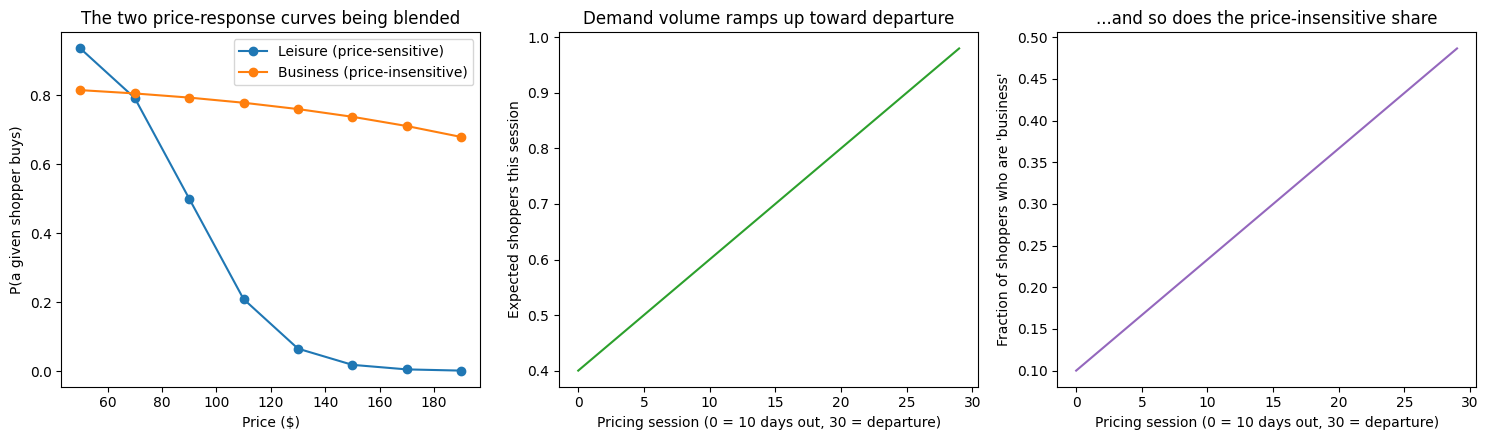

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(PRICE_OPTIONS, [leisure_price_response(p) for p in PRICE_OPTIONS], "o-", label="Leisure (price-sensitive)")
axes[0].plot(PRICE_OPTIONS, [business_price_response(p) for p in PRICE_OPTIONS], "o-", label="Business (price-insensitive)")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("P(a given shopper buys)")
axes[0].set_title("The two price-response curves being blended")
axes[0].legend()

periods = np.arange(TOTAL_PERIODS)
axes[1].plot(periods, [mean_shoppers(t) for t in periods], color="tab:green")
axes[1].set_xlabel("Pricing session (0 = 10 days out, 30 = departure)")
axes[1].set_ylabel("Expected shoppers this session")
axes[1].set_title("Demand volume ramps up toward departure")

axes[2].plot(periods, [business_mix(t) for t in periods], color="tab:purple")
axes[2].set_xlabel("Pricing session (0 = 10 days out, 30 = departure)")
axes[2].set_ylabel("Fraction of shoppers who are 'business'")
axes[2].set_title("...and so does the price-insensitive share")

plt.tight_layout()
plt.show()

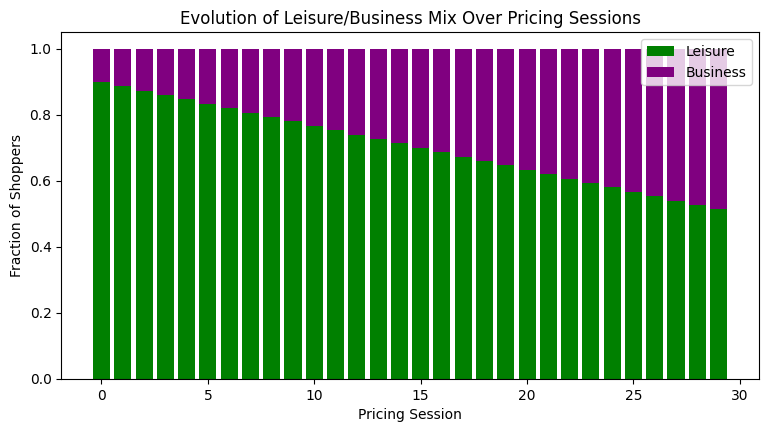

In [10]:
# plot how the leisure/business mix evolves over the 30 pricing sessions using bar plots
# where the height of each bar is the fraction of shoppers that are business (purple) vs. leisure (green)

periods = list(range(TOTAL_PERIODS))
mix_values = [business_mix(t) for t in periods]

plt.bar(periods, [1 - mix for mix in mix_values], color='green', label='Leisure')
plt.bar(periods, mix_values, color='purple', bottom=[1 - mix for mix in mix_values], label='Business')
plt.xlabel("Pricing Session")
plt.ylabel("Fraction of Shoppers")
plt.title("Evolution of Leisure/Business Mix Over Pricing Sessions")
plt.legend()
plt.show()

Demand or Expected shoppers in the middle graph, doesnt mean they will buy, just that they will check the prices.

On the left, is the probability that a shopper that appears will finally buy the ticket but just based on the price

Left panel: at low prices both segments buy readily; as price rises, leisure demand collapses almost to zero while business demand barely moves — exactly the segmentation that justifies discriminatory, state-aware pricing in the first place. Middle and right panels: both the number of shoppers *and* the fraction of them who are price-insensitive rise as departure approaches — more people are searching, and more of them don't care much about price. This creates a genuine, non-obvious tension: **selling too eagerly to cheap early leisure demand uses up seats that would have gone to a much higher-paying business traveler a week later.**

### Baselines, revisited

With this richer demand model, a single fixed price is even more clearly a compromise: a low price captures leisure shoppers but sells out too early to profit from business demand; a high price captures business demand but converts almost no one early on, when business travelers barely exist yet.

We add one more baseline this time, on top of the fixed-price sweep: a **hand-designed, two-tier heuristic** — charge a moderate price early, then switch to the highest price once business travellers are expected to dominate. This is a simulated version of a real airline tactic that predates any machine learning: deliberately holding a chunk of capacity out of the cheap fare buckets so it's still available for high-fare passengers later (formally, "nested fare classes" / capacity control).

In [11]:
N_EVAL_V2 = 2000

def run_fixed_price_v2(price, trials=N_EVAL_V2):
    revenues = []
    for _ in range(trials):
        capacity, total_revenue = TOTAL_CAPACITY, 0.0
        for t in range(TOTAL_PERIODS):
            if capacity <= 0:
                break
            sold, revenue = step_v2(t, capacity, price)
            capacity -= sold
            total_revenue += revenue
        revenues.append(total_revenue)
    return revenues

def run_protect_and_release(switch_at=10, early_price=90, late_price=190, trials=N_EVAL_V2):
    '''Charge `early_price` to filter for value, then `late_price` once business demand dominates.'''
    # switch_at = 10 means we switch to the late price after 10 pricing sessions
    revenues = []
    for _ in range(trials):
        capacity, total_revenue = TOTAL_CAPACITY, 0.0
        for t in range(TOTAL_PERIODS):
            if capacity <= 0:
                break
            price = late_price if t >= switch_at else early_price
            sold, revenue = step_v2(t, capacity, price)
            capacity -= sold
            total_revenue += revenue
        revenues.append(total_revenue)
    return revenues

baseline_results = {f"Fixed ${p}": run_fixed_price_v2(p) for p in PRICE_OPTIONS}
baseline_results["Protect-then-release heuristic"] = run_protect_and_release()

print(f"{'Strategy':<32}{'Avg revenue':>14}{'Std dev':>12}")
for name, revs in baseline_results.items():
    print(f"{name:<32}{np.mean(revs):>14.1f}{np.std(revs):>12.1f}")

Strategy                           Avg revenue     Std dev
Fixed $50                                828.3       110.9
Fixed $70                               1081.9       197.6
Fixed $90                               1097.8       296.3
Fixed $110                               899.2       312.7
Fixed $130                               768.7       310.8
Fixed $150                               777.8       350.1
Fixed $170                               810.0       372.0
Fixed $190                               863.5       413.8
Protect-then-release heuristic           995.2       402.0


The heuristic should beat every fixed price by a real margin (a few percent over the best single price in our runs) purely by deliberately under-pricing-and-under-selling early to protect capacity for the high-value business demand that hasn't shown up yet. That margin is the whole reason revenue management exists as a discipline, and it's the bar the RL agent needs to clear.

### Training the RL agent on the richer environment

Same recipe as the simple model — state = `(capacity, periods_remaining)`, action = index into `PRICE_OPTIONS`, epsilon-greedy Q-learning with a visit-count learning rate. Only the environment (`step_v2`) is new. We use fresh variable names (`Q_V2`, `VISITS_V2`, ...) so this section doesn't collide with the simple model's tables above.

Fair warning: the state space here (18 capacity levels × 30 remaining-periods ≈ 500+ states, × 8 actions) is roughly **5x bigger** than the simple model's, so this cell takes a few minutes to run.

In [12]:
GAMMA_V2 = 0.99
N_EPISODES_V2 = 300_000

def epsilon_schedule_v2(episode):
    return max(0.02, 1.0 - episode / (N_EPISODES_V2 * 0.3))

Q_V2 = {}
VISITS_V2 = {}
def get_q_v2(state):
    if state not in Q_V2:
        Q_V2[state] = np.zeros(len(PRICE_OPTIONS))
        VISITS_V2[state] = np.zeros(len(PRICE_OPTIONS))
    return Q_V2[state]

def run_episode_v2(policy="learn", epsilon=0.0):
    capacity, periods_elapsed = TOTAL_CAPACITY, 0
    total_revenue = 0.0
    while capacity > 0 and periods_elapsed < TOTAL_PERIODS:
        periods_remaining = TOTAL_PERIODS - periods_elapsed
        state = (capacity, periods_remaining)
        q = get_q_v2(state)
        if policy == "learn" and rng.random() < epsilon:
            action = rng.integers(len(PRICE_OPTIONS))
        else:
            action = int(np.argmax(q))
        price = PRICE_OPTIONS[action]

        sold, revenue = step_v2(periods_elapsed, capacity, price)
        next_capacity = capacity - sold
        next_periods_elapsed = periods_elapsed + 1
        total_revenue += revenue

        if policy == "learn":
            next_periods_remaining = TOTAL_PERIODS - next_periods_elapsed
            done = next_capacity == 0 or next_periods_elapsed >= TOTAL_PERIODS
            best_next = 0.0 if done else np.max(get_q_v2((next_capacity, next_periods_remaining)))
            td_target = revenue + GAMMA_V2 * best_next
            VISITS_V2[state][action] += 1
            alpha = 1.0 / VISITS_V2[state][action]
            q[action] += alpha * (td_target - q[action])

        capacity, periods_elapsed = next_capacity, next_periods_elapsed
    return total_revenue

training_revenues_v2 = []
for ep in range(N_EPISODES_V2):
    training_revenues_v2.append(run_episode_v2(policy="learn", epsilon=epsilon_schedule_v2(ep)))

print(f"Average revenue, first 2000 training episodes: {np.mean(training_revenues_v2[:2000]):.1f}")
print(f"Average revenue, last 2000 training episodes:  {np.mean(training_revenues_v2[-2000:]):.1f}")

Average revenue, first 2000 training episodes: 918.0
Average revenue, last 2000 training episodes:  1049.8


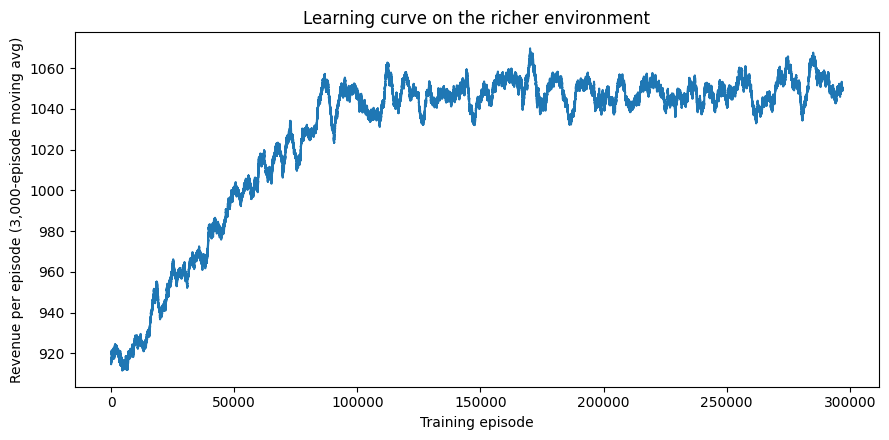

In [13]:
smoothed_v2 = np.convolve(training_revenues_v2, np.ones(3000)/3000, mode="valid")
plt.figure()
plt.plot(smoothed_v2)
plt.xlabel("Training episode")
plt.ylabel("Revenue per episode (3,000-episode moving avg)")
plt.title("Learning curve on the richer environment")
plt.tight_layout()
plt.show()

### RL vs. every baseline, head-to-head

Strategy                           Avg revenue     Std dev
Fixed $50                                828.3       110.9
Fixed $70                               1081.9       197.6
Fixed $90                               1097.8       296.3
Fixed $110                               899.2       312.7
Fixed $130                               768.7       310.8
Fixed $150                               777.8       350.1
Fixed $170                               810.0       372.0
Fixed $190                               863.5       413.8
Protect-then-release heuristic           995.2       402.0
Learned RL policy                       1068.3       343.1


C:\Users\Pablo\AppData\Local\Temp\ipykernel_22800\377271387.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(list(baseline_results.values()), labels=list(baseline_results.keys()), showmeans=True)


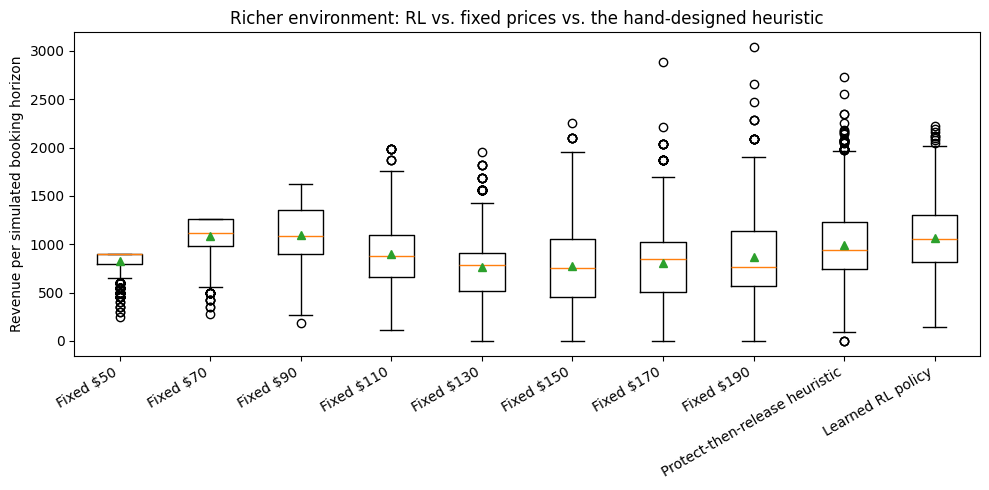

In [14]:
rl_revenues_v2 = [run_episode_v2(policy="learn", epsilon=0.0) for _ in range(N_EVAL_V2)]
baseline_results["Learned RL policy"] = rl_revenues_v2

print(f"{'Strategy':<32}{'Avg revenue':>14}{'Std dev':>12}")
for name, revs in baseline_results.items():
    print(f"{name:<32}{np.mean(revs):>14.1f}{np.std(revs):>12.1f}")

plt.figure(figsize=(10, 5))
plt.boxplot(list(baseline_results.values()), labels=list(baseline_results.keys()), showmeans=True)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Revenue per simulated booking horizon")
plt.title("Richer environment: RL vs. fixed prices vs. the hand-designed heuristic")
plt.tight_layout()
plt.show()

### Being honest about what actually happened

Here's the result you should expect, and it's a more interesting (and more useful) outcome than "RL wins again": **the RL agent learns a real policy that roughly matches the best fixed price, but it typically does *not* close the gap to the hand-designed protect-then-release heuristic.** That's worth sitting with, because unlike the earlier "gray cells" coverage issue, this isn't just a rarely-visited-state problem — it shows up even in states the agent visits constantly. Two things compound here:

1. **A noisier reward signal.** In the simple model, every outcome was a clean yes/no — easy to average out with a moderate number of samples. Here, the reward each period is `price × Binomial(n_shoppers, conversion_prob)`, which can be 0, 1, 2, or more sales — a lot more randomness per observation. Telling apart two prices whose *true* expected values are close (which is common — look back at the price-response curves; several nearby prices often have similar expected revenue per shopper) now needs many more samples to be confident which one is actually better.
2. **A "hold your nerve" strategy is hard for undirected exploration to stumble into.** The heuristic's edge comes from *consistently* pricing high for many consecutive early periods to protect capacity — a coordinated, multi-step choice. Epsilon-greedy explores by randomly trying a different action *at each individual step*, independent of what it did the step before. That's great for problems where one step's choice mostly speaks for itself (like the simple model), but it's a genuinely inefficient way to discover a strategy whose payoff only shows up several steps later, after a sustained deviation from what looks best right now. This is a well-known, named issue in RL — a **hard exploration problem** — and it's *why* more advanced methods exist (optimistic initialization, upper-confidence-bound exploration, or intrinsic-motivation bonuses that explicitly reward the agent for trying under-explored *sequences*, not just under-explored single actions).

Put together with the bigger state space (roughly 5x more states than the simple model, each now needing more samples per state instead of fewer): **this is tabular Q-learning meeting a real, practical ceiling.**

### Where does that leave the coverage check from before?

Let's rerun the same visit-count masking trick from the simple model, on this bigger state space.

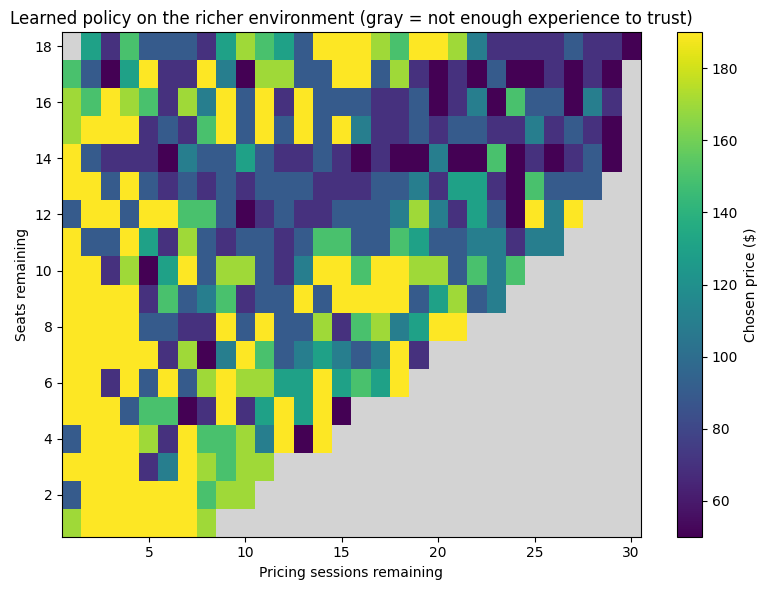

In [15]:
MIN_VISITS_TO_TRUST_V2 = 50

policy_grid_v2 = np.full((TOTAL_CAPACITY, TOTAL_PERIODS), np.nan)
for capacity in range(1, TOTAL_CAPACITY + 1):
    for periods_remaining in range(1, TOTAL_PERIODS + 1):
        state = (capacity, periods_remaining)
        if state in VISITS_V2 and VISITS_V2[state].sum() >= MIN_VISITS_TO_TRUST_V2:
            q = get_q_v2(state)
            policy_grid_v2[capacity - 1, periods_remaining - 1] = PRICE_OPTIONS[int(np.argmax(q))]

cmap = plt.get_cmap("viridis").copy()
cmap.set_bad(color="lightgray")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(policy_grid_v2, aspect="auto", origin="lower", cmap=cmap,
               extent=[0.5, TOTAL_PERIODS + 0.5, 0.5, TOTAL_CAPACITY + 0.5])
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Chosen price ($)")
ax.set_xlabel("Pricing sessions remaining")
ax.set_ylabel("Seats remaining")
ax.set_title("Learned policy on the richer environment (gray = not enough experience to trust)")
plt.tight_layout()
plt.show()

Two things to notice, both consistent with the story above:

- The trustworthy (non-gray) band is **narrower** relative to the full grid than it was in the simple model — a direct, visible consequence of the bigger state space spreading the same training budget thinner.
- Even inside the trustworthy band, the price choices are **noisier and less monotonic** than the clean diagonal gradient we saw in the simple model — the visible fingerprint of the higher per-step variance discussed above. The agent isn't wrong so much as *unconfident*: several prices in a given state may have nearly identical true value, so which one wins the `argmax` is partly a coin flip baked in from early training.

### The business lesson, not just the technical one

If you were presenting this to a revenue-management team, the honest pitch is **not** "replace your heuristics with this." It's something more useful:

- The hand-designed protect-then-release heuristic is exactly the kind of policy real airlines have used for decades (nested fare classes, EMSR-style capacity control) — and it's robust *precisely because* it doesn't need to be learned from scratch by trial and error. It encodes the analyst's understanding that early demand is cheap and business demand is valuable, directly.
- Plain tabular Q-learning is a fantastic tool for *discovering* a good policy when you don't already know the shape of the answer (as in the simple model, or notebook 4's inventory problem, where it matched a strong classical baseline). It's a much harder tool to lean on once the environment is this stochastic and this large — not because RL as an idea has failed, but because *this specific, simplest implementation of it* (a table, epsilon-greedy, from-scratch) has real, known limits.
- The actual path forward in industry is rarely "give up on RL" — it's to fix the specific bottleneck: more training data/compute, smarter exploration (UCB/Thompson sampling for the pricing action itself), reward shaping, or swapping the table for a neural network (deep RL) so the agent can generalize across similar states instead of learning each one from scratch. Recognizing *which* of those levers applies is a more valuable skill than a demo where RL always wins.

Next: **inventory management**, where instead of *selling down* a fixed stock, the agent has to decide *how much to reorder* under uncertain demand — adding a control dial (order quantity) that changes the state itself, rather than just how fast it depletes.